In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("../dataset/station-hourly.csv", sep=";")

In [5]:
df.head()


,Date,Hour,Station,Ridership
0,2025-08-01,0,Attiguppe,0
1,2025-08-01,1,Attiguppe,0
2,2025-08-01,2,Attiguppe,0
3,2025-08-01,3,Attiguppe,0
4,2025-08-01,4,Attiguppe,6


In [6]:
# Cell 1
import pandas as pd

In [7]:
df.head()

,Date,Hour,Station,Ridership
0,2025-08-01,0,Attiguppe,0
1,2025-08-01,1,Attiguppe,0
2,2025-08-01,2,Attiguppe,0
3,2025-08-01,3,Attiguppe,0
4,2025-08-01,4,Attiguppe,6


In [8]:
df.columns

Index(['Date', 'Hour', 'Station', 'Ridership'], dtype='object')

In [9]:
df.shape

(92280, 4)

In [10]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92280 entries, 0 to 92279
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       92280 non-null  object
 1   Hour       92280 non-null  int64 
 2   Station    92280 non-null  object
 3   Ridership  92280 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.8+ MB


In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
df.dtypes

Date         datetime64[ns]
Hour                  int64
Station              object
Ridership             int64
dtype: object

In [13]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [14]:
df.head()

,Date,Hour,Station,Ridership,Day,Month,DayOfWeek
0,2025-08-01,0,Attiguppe,0,1,8,4
1,2025-08-01,1,Attiguppe,0,1,8,4
2,2025-08-01,2,Attiguppe,0,1,8,4
3,2025-08-01,3,Attiguppe,0,1,8,4
4,2025-08-01,4,Attiguppe,6,1,8,4


In [15]:
df_model = pd.get_dummies(df, columns=['Station'], drop_first=True)

In [16]:
df_model.head()

,Date,Hour,Ridership,Day,Month,DayOfWeek,Station_BTM Layout,Station_Baiyappanahalli,Station_Banashankari,Station_Benniganahalli,...,Station_Sri Sathya Sai Hospital,Station_Srirampura,Station_Swami Vivekananda Road,Station_Thalaghattapura,Station_Trinity,Station_Vajarahalli,Station_Vijayanagar,Station_Whitefield (Kadugodi),Station_Yelachenahalli,Station_Yeshwantpur
0,2025-08-01,0,0,1,8,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2025-08-01,1,0,1,8,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2025-08-01,2,0,1,8,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2025-08-01,3,0,1,8,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2025-08-01,4,6,1,8,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
X = df_model.drop(columns=['Date', 'Ridership'])
y = df_model['Ridership']

In [18]:
X.head()

,Hour,Day,Month,DayOfWeek,Station_BTM Layout,Station_Baiyappanahalli,Station_Banashankari,Station_Benniganahalli,Station_Beratena Agrahara,Station_Biocon Hebbagodi,...,Station_Sri Sathya Sai Hospital,Station_Srirampura,Station_Swami Vivekananda Road,Station_Thalaghattapura,Station_Trinity,Station_Vajarahalli,Station_Vijayanagar,Station_Whitefield (Kadugodi),Station_Yelachenahalli,Station_Yeshwantpur
0,0,1,8,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,8,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,1,8,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,1,8,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,1,8,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [21]:
y_pred = model.predict(X_test)

In [22]:
y_pred[:10]

array([  0.  , 266.84, 720.4 , 616.74,  87.38,   1.61,  13.82, 351.76,
       232.9 , 701.14])

In [23]:
df.columns

Index(['Date', 'Hour', 'Station', 'Ridership', 'Day', 'Month', 'DayOfWeek'], dtype='object')

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 41.11565507152145
Root Mean Squared Error (RMSE): 87.5633541389519
R² Score: 0.9681853667119555


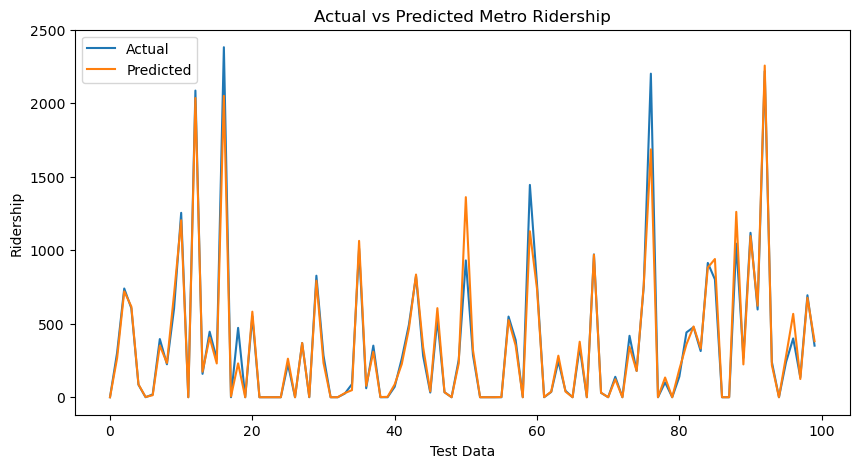

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.xlabel("Test Data")
plt.ylabel("Ridership")
plt.title("Actual vs Predicted Metro Ridership")
plt.legend()

plt.show()

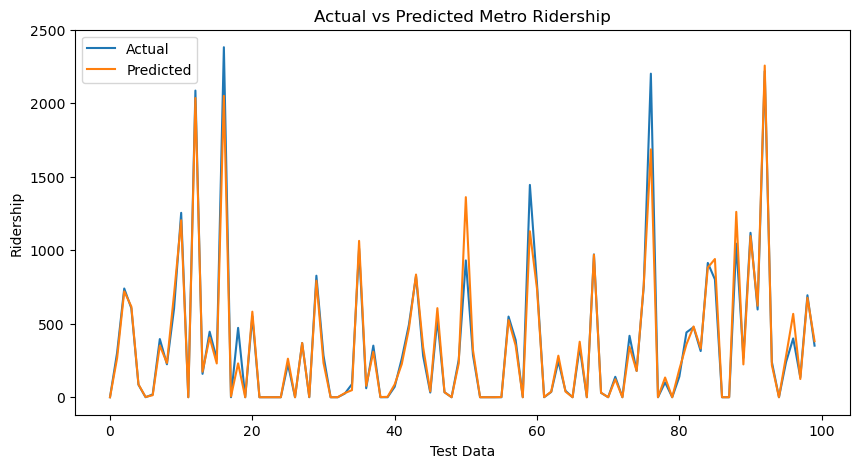

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.xlabel("Test Data")
plt.ylabel("Ridership")
plt.title("Actual vs Predicted Metro Ridership")
plt.legend()

plt.show()